# 11b — Caruana Ensemble Selection

**Reporting only -- nothing here retrains anything, and nothing here touches
the blind test set.** This notebook loads the per-isoform OOF matrices built
by `11_caruana_prep.ipynb` (themselves assembled from already-computed
`05_cv_comparison` predictions, no retraining), runs `src.ensemble.caruana.
caruana_bagged_selection` per isoform, and compares the result in CV against
(i) the single best of the 11-config pool and (ii) notebook 08's original
ensemble for that isoform, read directly from 08's saved outputs. It does not
read or reference `test_blinded_curated.csv` anywhere, per this project's
rule that the blind test set is single-use evidence, never training/selection
signal.

**Why this rebuild exists:** notebook 08 picked each isoform's ensemble by
exhaustively scoring every non-trivial subset of a small candidate pool and
keeping whichever scored best in CV -- selecting the best-scoring candidate
out of several similar options using the same CV data used to score them, a
known overfitting risk (Caruana et al. 2004). Notebook 10's blind submission
regressed on every isoform, and notebook 10b traced the CV margins that
justified 08's ensembles to have been largely erased on blind data for the
three ensembled isoforms -- consistent with, though not conclusively isolated
to, that selection-bias mechanism (10c's environment-migration control is the
other half of that investigation). This notebook tests a specific mitigation
Caruana et al. (2004) proposed for exactly this failure mode -- bagged
selection over random library subsets -- against a **wider** candidate pool
(all 11 real configs from 05, not just 08's small CLD-tier subset).

**A rebuild is not automatically an improvement.** This notebook reports
whichever answer the numbers give, including "no different" or "worse," for
every isoform.

## Revision — why a size cap and a fresh placement check

`12b_caruana_vs_control_comparison.ipynb` found that notebook 12's
Caruana-weighted ensembles (9-11 members per isoform, the uncapped result
this notebook originally produced) compress blind prediction spread more
severely, and more universally, than notebook 10's smaller ensembles did --
narrower than 10c's control on **every** isoform, not just the three 08 ever
ensembled. This is a **mechanical property of averaging**, not a
selection-bias flaw: Caruana's own objective (minimize pooled ST-RAE on the
hillclimbing set) has no term that protects prediction spread, and averaging
more, even imperfectly-correlated members mechanically shrinks combined
variance further the more members are included -- exactly what a library of
9-11 members does more of than 08's library of 2-4 ever could.

Two real-entrant precedents motivate the fix pursued below, both already
reviewed in this project:
- **SuperCowPowers** (`supercowpowers.github.io/workbench/blogs/
  cyp_challenge/`, already cited in notebook 09) found a 4th ensemble member
  added almost nothing and a 5th actively hurt -- they capped their own
  ensembles small (2-3 members) rather than using everything available.
- **`jeremycheminf/openadmet_scripts`** (already reviewed for `caruana.py`
  and `calibration.py` in notebooks 11b/09) offers both raw and calibrated
  versions of each model as *separate* Caruana candidates in its library,
  letting selection itself correct for shrinkage directly rather than
  needing a bolt-on placement-correction step afterward.

This revision pursues the more direct, more surgical fix for *this*
project's existing pipeline: a **marginal-value-informed size cap** per
isoform (Task 1 below), then a **fresh placement-correction check scoped to
the capped ensemble specifically** (Task 2 below) -- notebook 09's original
recalibration parameters were computed for notebook 08's ensembles and are
not reused here.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import importlib.metadata
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon
from sklearn.metrics import r2_score

from src.cv_bootstrap import per_fold_bootstrap_seed
from src.ensemble.caruana import caruana_bagged_selection
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS
from src.vendor.openadmet_eval.evaluate_predictions import score_activity_predictions

# Surfaces src.ensemble.caruana's logger.info calls (hyperparameters, every bag's
# outcome, final weights) directly in this notebook's output.
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "seaborn", "matplotlib", "scikit-learn"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

OUT05 = REPO_ROOT / "outputs" / "05_cv_comparison"
OUT08 = REPO_ROOT / "outputs" / "08_ensemble_selection"
OUT11PREP = REPO_ROOT / "outputs" / "11_caruana_prep"
OUT = REPO_ROOT / "outputs" / "11b_caruana_selection"
PRED_OUT, SCORE_OUT, FIG_OUT = OUT / "predictions", OUT / "scores", OUT / "figures"
for d in (PRED_OUT, SCORE_OUT, FIG_OUT):
    d.mkdir(parents=True, exist_ok=True)

SCORE_DIR_05 = OUT05 / "scores"

CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
curated = pd.read_csv(CURATED_PATH)
print(f"\ncurated: {curated.shape}")

N_REPEATS, N_FOLDS = 5, 5
ISOFORMS = ["CYP1A2", "CYP2C9", "CYP2D6", "CYP3A4"]  # matches config.REGRESSION_ENDPOINTS order
ISOFORM_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
ALPHA = 0.05
METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
METRICS = ["ST-RAE"]

# Bootstrap seed is shared across every config for a given (repeat, fold) -- same
# manifest 08 used, same reasoning: fold-varying, never a single global seed.
manifest = pd.read_csv(OUT05 / "manifest.csv")
seed_lookup = manifest.drop_duplicates(["repeat", "fold"]).set_index(["repeat", "fold"])["seed"]
assert manifest.groupby(["repeat", "fold"])["seed"].nunique().eq(1).all(), "seed not shared across configs for some fold"
print(f"fold seeds loaded: {len(seed_lookup)} (repeat, fold) pairs")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
seaborn: 0.13.2
matplotlib: 3.11.1
scikit-learn: 1.9.0

curated: (4905, 20)
fold seeds loaded: 25 (repeat, fold) pairs


**What this shows:** the curated dataset, 05's fold-seed manifest, and the
vendored evaluator all load cleanly -- same reused infrastructure as
notebooks 05-09, nothing reimplemented.

## Caruana hyperparameters -- explicit, no silent defaults

Per `src/ensemble/caruana.py`'s signature, every hyperparameter below is a
required argument with no default in that module -- they are set here,
explicitly, and logged by the function itself when called. Values match
`jeremycheminf/openadmet_scripts`'s `CYP_Challenge/src/cyp_submission/
caruana.py` (fetched and reviewed this session as the working-implementation-
pattern reference named in this task's brief -- see `src/ensemble/caruana.py`'s
module docstring for the full provenance note, including why that file was
not actually available locally in this project despite being described that
way, and the deliberate early-stopping design choice adopted from it), now
that they are a reviewed community reference for this exact challenge rather
than an arbitrary guess. **Unchanged by this revision** -- the size cap and
placement check below operate on the same bagged-selection output these
hyperparameters produce, not on the selection algorithm itself.

In [2]:
N_BAGS = 20      # bagging iterations (Caruana Sec. 2.3)
BAG_FRAC = 0.5   # fraction of the 11-config library sampled per bag
N_INIT = 1       # individually-best configs used to seed each bag's ensemble (Sec. 2.2)
MAX_ITER = 50    # upper bound on greedy additions per bag (Sec. 2.1); bags stop earlier on no improvement
SEED = 42        # master seed; per-bag seeds are drawn from this and logged individually

print(f"Caruana hyperparameters: n_bags={N_BAGS}, bag_frac={BAG_FRAC}, n_init={N_INIT}, max_iter={MAX_ITER}, seed={SEED}")


Caruana hyperparameters: n_bags=20, bag_frac=0.5, n_init=1, max_iter=50, seed=42


## Load 11-config OOF matrices (`11_caruana_prep`)

One `oof_long_{isoform}.csv` per isoform, already validated by that notebook
(exactly 11 configs, zero unexpected NaNs, row counts matching
`n_unique_compounds x 5 repeats`). Re-checked here too, rather than trusted
blindly, since this notebook is a separate, independently-runnable unit.

In [3]:
prep_manifest = pd.read_csv(OUT11PREP / "manifest.csv")
print(prep_manifest.drop(columns="configs").to_string(index=False))

ALL_11_CONFIGS = prep_manifest.loc[0, "configs"].split("|")
assert len(ALL_11_CONFIGS) == 11, f"expected exactly 11 configs, got {len(ALL_11_CONFIGS)}"
assert (prep_manifest["configs"] == prep_manifest.loc[0, "configs"]).all(), "config list differs across isoforms in 11_caruana_prep's manifest"
print(f"\ncandidate library ({len(ALL_11_CONFIGS)} configs): {ALL_11_CONFIGS}")

oof_tables = {}
for isoform in ISOFORMS:
    path = OUT11PREP / f"oof_long_{isoform}.csv"
    df = pd.read_csv(path)
    check_cols = ["y_true", "conf_low", "conf_high"] + ALL_11_CONFIGS
    n_nan = int(df[check_cols].isna().sum().sum())
    if n_nan > 0:
        raise ValueError(f"{isoform}: {n_nan} unexpected NaNs in {path} -- stopping, not proceeding on a partial matrix")
    if not set(ALL_11_CONFIGS).issubset(df.columns):
        raise ValueError(f"{isoform}: {path} is missing one or more of the 11 expected config columns")
    oof_tables[isoform] = df
    print(f"{isoform}: loaded {path.name}: {df.shape}, {df['inchikey'].nunique()} unique compounds, 0 unexpected NaNs")


isoform  n_rows  n_unique_compounds  n_repeats  n_folds  n_configs
 CYP1A2    7060                1412          5        5         11
 CYP2C9    6425                1285          5        5         11
 CYP2D6    7465                1493          5        5         11
 CYP3A4   11675                2335          5        5         11

candidate library (11 configs): ['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'chemprop_chemeleoninit', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost']
CYP1A2: loaded oof_long_CYP1A2.csv: (7060, 18), 1412 unique compounds, 0 unexpected NaNs
CYP2C9: loaded oof_long_CYP2C9.csv: (6425, 18), 1285 unique compounds, 0 unexpected NaNs
CYP2D6: loaded oof_long_CYP2D6.csv: (7465, 18), 1493 unique compounds, 0 unexpected NaNs
CYP3A4: loaded oof_long_CYP3A4.csv: (11675, 18), 2335 unique compounds, 0 unexpected NaNs


**What this shows:** all four isoforms' OOF matrices load with exactly 11
config columns and zero unexpected NaNs -- the two conditions this task said
to stop and flag on if violated. Neither triggered.

## Shared scoring helpers

Two scoring paths, deliberately different, per `src/ensemble/caruana.py`'s
own docstring: the module's internal greedy search calls the plain ST-RAE
function directly (fast, no bootstrap -- appropriate for a hillclimbing
objective evaluated thousands of times). Everything **reported** below
instead goes through this project's full bootstrap pipeline
(`score_activity_predictions` + `per_fold_bootstrap_seed`, point estimate =
mean of the 1,000-sample bootstrap distribution), one call per `(repeat,
fold)` -- identical to notebook 08's own `score_predictions`/
`point_estimate`/`load_existing_fold_scores`/`paired_test` functions,
reproduced here (this project's notebooks keep such helpers notebook-local
rather than factored into a shared module, matching 08/09's own precedent)
so this notebook's reported numbers are directly comparable, fold for fold,
to 08's. `score_weighted_ensemble_mean_only` (added this revision) is the
same weighted-average + bootstrap-scoring logic without the per-fold disk
writes, used for the marginal-value trajectory below where up to 10 weight
subsets are scored per isoform and per-fold files for all of them would
just be clutter -- only the final chosen ensemble's per-fold files are
persisted, via `score_weighted_ensemble_per_fold`.

In [4]:
def score_predictions(pred_df: pd.DataFrame, isoform_col: str, seed: int) -> pd.DataFrame:
    """Score one (repeat, fold)'s predictions for one isoform column through the
    vendored bootstrap pipeline, using that fold's manifest seed. Identical
    pattern to notebook 08's `score_predictions`."""
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(int(seed)):
        scored = score_activity_predictions(pred_df[["Molecule_Name", "inchikey", isoform_col]], ground_truth, [isoform_col])
    return scored


def point_estimate(scored: pd.DataFrame, isoform_col: str) -> dict:
    pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
    return {m: float(pe.loc[isoform_col, m]) for m in METRICS}


def load_existing_fold_scores(score_dir: Path, tag: str, isoform_col: str) -> pd.DataFrame:
    """Load an already-computed model's 25 per-fold point estimates directly from
    its existing score CSVs on disk -- no new bootstrap run, matching notebook
    08's `load_existing_fold_scores`."""
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = score_dir / f"{tag}__repeat{repeat}_fold{fold}.csv"
            pe = point_estimate(pd.read_csv(path), isoform_col)
            rows.append({"repeat": repeat, "fold": fold, **pe})
    return pd.DataFrame(rows).sort_values(["repeat", "fold"]).reset_index(drop=True)


def score_weighted_ensemble_per_fold(oof_df: pd.DataFrame, isoform_col: str, weights: dict, tag_prefix: str) -> pd.DataFrame:
    """Apply a fixed Caruana weight vector to build a weighted-average prediction
    per (repeat, fold), score each fold through the full bootstrap pipeline
    (matching 08's per-combo scoring exactly), save predictions+scores to disk,
    and return the 25 per-fold point estimates."""
    nonzero = {c: w for c, w in weights.items() if w > 0}
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            fold_df = oof_df[(oof_df["repeat"] == repeat) & (oof_df["fold"] == fold)]
            pred_df = fold_df[["Molecule_Name", "inchikey"]].copy()
            pred_df[isoform_col] = sum(fold_df[c] * w for c, w in nonzero.items())

            seed = int(seed_lookup.loc[(repeat, fold)])
            scored = score_predictions(pred_df, isoform_col, seed)
            scored["repeat"], scored["fold"], scored["bootstrap_seed"] = repeat, fold, seed

            tag = f"{tag_prefix}__repeat{repeat}_fold{fold}"
            pred_df.to_csv(PRED_OUT / f"{tag}.csv", index=False)
            scored.to_csv(SCORE_OUT / f"{tag}.csv", index=False)

            rows.append({"repeat": repeat, "fold": fold, **point_estimate(scored, isoform_col)})
    return pd.DataFrame(rows).sort_values(["repeat", "fold"]).reset_index(drop=True)


def score_weighted_ensemble_mean_only(oof_df: pd.DataFrame, isoform_col: str, weights: dict) -> float:
    """Same weighted-average + full-bootstrap scoring as `score_weighted_ensemble_
    per_fold`, but returns only the mean CV ST-RAE (no disk writes) -- for scoring
    many candidate weight subsets cheaply (relative to training, not relative to
    the bootstrap itself -- this still runs the real 1,000-sample bootstrap per
    fold, not a proxy)."""
    fold_scores = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            fold_df = oof_df[(oof_df["repeat"] == repeat) & (oof_df["fold"] == fold)]
            pred_df = fold_df[["Molecule_Name", "inchikey"]].copy()
            pred_df[isoform_col] = sum(fold_df[c] * w for c, w in weights.items())
            seed = int(seed_lookup.loc[(repeat, fold)])
            scored = score_predictions(pred_df, isoform_col, seed)
            fold_scores.append(point_estimate(scored, isoform_col)["ST-RAE"])
    return float(np.mean(fold_scores))


def paired_test(before: np.ndarray, after: np.ndarray) -> dict:
    """Shapiro-Wilk on the 25 (after - before) deltas; paired t-test if normal,
    Wilcoxon signed-rank otherwise. No BH/Bonferroni correction -- identical
    method to 06/07/08's own before/after comparisons."""
    delta = after - before
    shapiro_p = float(shapiro(delta).pvalue)
    normal = shapiro_p >= ALPHA
    if normal:
        test_name, (_, p_value) = "paired t-test", ttest_rel(after, before)
    else:
        test_name, (_, p_value) = "Wilcoxon signed-rank", wilcoxon(delta)
    return {
        "before_mean": float(before.mean()), "after_mean": float(after.mean()), "delta_mean": float(delta.mean()),
        "shapiro_p": shapiro_p, "branch": "parametric" if normal else "nonparametric",
        "test": test_name, "p_value": float(p_value), "significant": bool(p_value < ALPHA),
    }


## Step 1 — run Caruana bagged selection, per isoform (uncapped)

For each isoform: run `caruana_bagged_selection` on that isoform's pooled
25-fold OOF matrix (all 11 configs) and report the resulting weights. This is
the **uncapped** result -- the same one notebook 12b found compresses blind
prediction spread on every isoform. It is the necessary input to Step 2's
marginal-value analysis (member ordering) below, and is kept, unmodified, as
the "before" reference throughout this notebook.

In [5]:
uncapped_weights = {}
for isoform in ISOFORMS:
    print(f"\n{'=' * 80}\n{isoform}\n{'=' * 80}")
    isoform_col = ISOFORM_COL[isoform]
    df = oof_tables[isoform]

    oof_matrix = df[ALL_11_CONFIGS].to_numpy()
    y_true = df["y_true"].to_numpy()
    conf_low = df["conf_low"].to_numpy()
    conf_high = df["conf_high"].to_numpy()

    weights = caruana_bagged_selection(
        oof_matrix, y_true, conf_low, conf_high, ALL_11_CONFIGS,
        n_bags=N_BAGS, bag_frac=BAG_FRAC, n_init=N_INIT, max_iter=MAX_ITER, seed=SEED,
    )
    uncapped_weights[isoform] = weights
    nonzero = {k: v for k, v in weights.items() if v > 0}
    print(f"\n{isoform}: {len(nonzero)}/{len(ALL_11_CONFIGS)} configs received non-zero weight:")
    for k, v in sorted(nonzero.items(), key=lambda kv: -kv[1]):
        print(f"    {k}: {v:.4f}")

weights_uncapped_df = pd.DataFrame(
    [{"isoform": iso, "config": c, "weight": w} for iso in ISOFORMS for c, w in uncapped_weights[iso].items()]
)
weights_uncapped_path = OUT / "weights_uncapped.csv"
weights_uncapped_df.to_csv(weights_uncapped_path, index=False)
print(f"\nwrote {weights_uncapped_path} ({weights_uncapped_df.shape}) -- preserved for the before/after comparison below")


Caruana bagged selection starting: n_samples=7060, n_configs=11, configs=['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'chemprop_chemeleoninit', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost'], hyperparameters={'n_bags': 20, 'bag_frac': 0.5, 'n_init': 1, 'max_iter': 50, 'seed': 42}


bag seeds (drawn from master seed=42): [191664963, 1662057957, 1405681631, 942484272, 929893137, 1843824992, 184566854, 1497586438, 432652533, 202244314, 1130604997, 2095133045, 1580016183, 1634535062, 1540770719, 1688060240, 1102145672, 275121930, 1803345590, 967196436]


  bag 0 (seed=191664963): library subset=['chemeleon__lightgbm', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf'] -> selected=['ecfp4_narrow__lightgbm', 'chemprop_randominit', 'chemeleon__lightgbm', 'mordred_pca__lightgbm', 'ecfp4_narrow__lightgbm', 'chemprop_randominit', 'ecfp4_narrow__xgboost'] (final ST-RAE=0.8092, 6 greedy addition(s) beyond the 1-model init, cap was 50)


  bag 1 (seed=1662057957): library subset=['chemeleon__xgboost', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost'] -> selected=['ecfp4_narrow__lightgbm', 'mordred_pca__lightgbm', 'ecfp4_narrow__lightgbm', 'chemeleon__xgboost', 'ecfp4_narrow__xgboost', 'ecfp4_narrow__lightgbm', 'mordred_pca__lightgbm', 'ecfp4_narrow__lightgbm'] (final ST-RAE=0.8373, 7 greedy addition(s) beyond the 1-model init, cap was 50)


  bag 2 (seed=1405681631): library subset=['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'ecfp4_narrow__rf', 'mordred_pca__lightgbm', 'mordred_pca__rf'] -> selected=['ecfp4_narrow__rf', 'chemeleon__rf'] (final ST-RAE=0.8322, 1 greedy addition(s) beyond the 1-model init, cap was 50)


...

  bag 18 (seed=1803345590): library subset=['chemeleon__rf', 'chemprop_chemeleoninit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__xgboost'] -> selected=['chemprop_chemeleoninit', 'ecfp4_narrow__lightgbm'] (final ST-RAE=0.5014, 1 greedy addition(s) beyond the 1-model init, cap was 50)


  bag 19 (seed=967196436): library subset=['chemeleon__rf', 'chemprop_chemeleoninit', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__rf', 'mordred_pca__xgboost'] -> selected=['chemprop_chemeleoninit', 'ecfp4_narrow__rf', 'chemprop_chemeleoninit'] (final ST-RAE=0.5061, 2 greedy addition(s) beyond the 1-model init, cap was 50)


final weights (selection frequency across 20 bags, 81 total selections): {'chemeleon__lightgbm': 0.1358, 'chemeleon__rf': 0.0247, 'chemeleon__xgboost': 0.037, 'chemprop_chemeleoninit': 0.2222, 'chemprop_randominit': 0.1235, 'ecfp4_narrow__lightgbm': 0.1852, 'ecfp4_narrow__rf': 0.1975, 'ecfp4_narrow__xgboost': 0.0617, 'mordred_pca__lightgbm': 0.0123}



CYP3A4: 9/11 configs received non-zero weight:
    chemprop_chemeleoninit: 0.2222
    ecfp4_narrow__rf: 0.1975
    ecfp4_narrow__lightgbm: 0.1852
    chemeleon__lightgbm: 0.1358
    chemprop_randominit: 0.1235
    ecfp4_narrow__xgboost: 0.0617
    chemeleon__xgboost: 0.0370
    chemeleon__rf: 0.0247
    mordred_pca__lightgbm: 0.0123



wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/weights_uncapped.csv ((44, 3)) -- preserved for the before/after comparison below


**What this shows:** the same uncapped selection this notebook originally
produced (9-11 non-zero-weight configs per isoform) -- unchanged, since the
selection algorithm itself is not what's being revised. `weights_uncapped.csv`
preserves it on disk before `weights.csv` gets overwritten with the capped
result later in this notebook.

## Step 2 — marginal CV value of each additional member (REQUIRED PLOT)

Per isoform, order the non-zero-weight configs by descending weight (highest
selection frequency first) and compute cumulative mean CV ST-RAE (full
bootstrap pipeline, same as everywhere else in this notebook) as members are
added one at a time in that order. This directly shows where the marginal
value of an additional member plateaus -- informed by, but not required to
match, SuperCowPowers' own ~2-3-member finding (their candidate pool, data,
and metric all differ from this project's).

In [6]:
trajectory_rows = []
for isoform in ISOFORMS:
    isoform_col = ISOFORM_COL[isoform]
    df = oof_tables[isoform]
    iso_weights = pd.Series({c: w for c, w in uncapped_weights[isoform].items() if w > 0}).sort_values(ascending=False)
    ordered_configs = iso_weights.index.tolist()
    print(f"{isoform}: {len(ordered_configs)} members in weight-descending order: {ordered_configs}")

    for k in range(1, len(ordered_configs) + 1):
        top_k = ordered_configs[:k]
        top_k_w = iso_weights.loc[top_k]
        renorm_w = (top_k_w / top_k_w.sum()).to_dict()
        mean_st_rae = score_weighted_ensemble_mean_only(df, isoform_col, renorm_w)
        trajectory_rows.append({"isoform": isoform, "k": k, "mean_ST-RAE": mean_st_rae, "members_included": "+".join(top_k)})
        print(f"  k={k:2d}  mean_ST-RAE={mean_st_rae:.4f}")

trajectory_df = pd.DataFrame(trajectory_rows)
trajectory_path = OUT / "marginal_value_trajectory.csv"
trajectory_df.to_csv(trajectory_path, index=False)
print(f"\nwrote {trajectory_path} ({trajectory_df.shape})")


2026-09-04 11:13:32.547 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-04 11:13:32.548 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 277 rows and 22 columns.


2026-09-04 11:13:32.548 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


CYP1A2: 10 members in weight-descending order: ['ecfp4_narrow__rf', 'chemprop_chemeleoninit', 'chemeleon__rf', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'mordred_pca__lightgbm', 'chemeleon__lightgbm', 'ecfp4_narrow__xgboost', 'chemeleon__xgboost', 'mordred_pca__xgboost']


2026-09-04 11:13:33.133 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


...

2026-09-04 11:23:22.847 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-04 11:23:22.849 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 495 rows and 22 columns.


2026-09-04 11:23:22.849 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-04 11:23:23.484 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


  k= 9  mean_ST-RAE=0.4992

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/marginal_value_trajectory.csv ((39, 4))


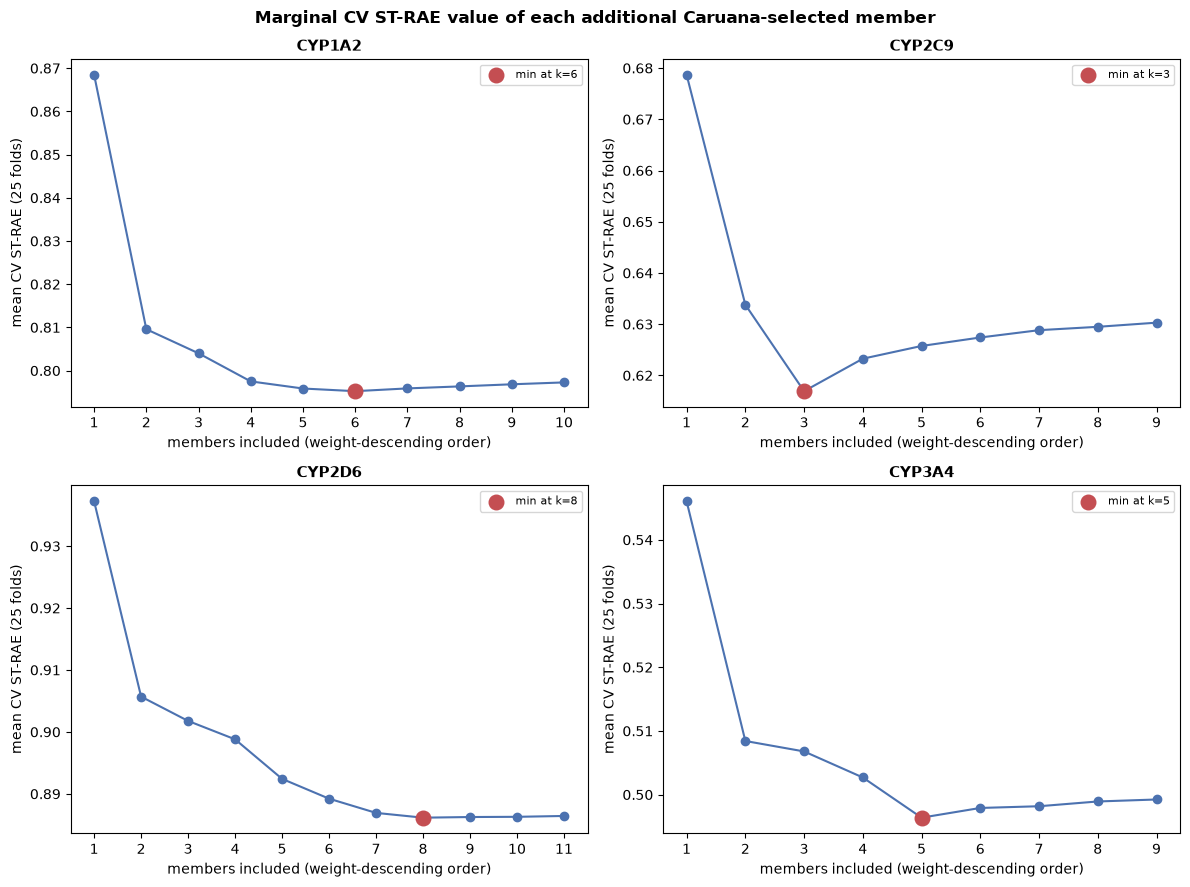

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/figures/marginal_value_by_isoform.png

empirical CV-minimizing k per isoform: {'CYP1A2': 6, 'CYP2C9': 3, 'CYP2D6': 8, 'CYP3A4': 5}


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
best_k_by_isoform = {}
for ax, isoform in zip(axes.flat, ISOFORMS):
    g = trajectory_df[trajectory_df["isoform"] == isoform].sort_values("k")
    ax.plot(g["k"], g["mean_ST-RAE"], marker="o", color="#4C72B0")
    best_row = g.loc[g["mean_ST-RAE"].idxmin()]
    best_k_by_isoform[isoform] = int(best_row["k"])
    ax.scatter([best_row["k"]], [best_row["mean_ST-RAE"]], color="#C44E52", s=110, zorder=5, label=f"min at k={int(best_row['k'])}")
    ax.set_xlabel("members included (weight-descending order)")
    ax.set_ylabel("mean CV ST-RAE (25 folds)")
    ax.set_title(isoform, fontsize=11, fontweight="bold")
    ax.set_xticks(g["k"])
    ax.legend(fontsize=8)

fig.suptitle("Marginal CV ST-RAE value of each additional Caruana-selected member", fontsize=12, fontweight="bold")
plt.tight_layout()
path = FIG_OUT / "marginal_value_by_isoform.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path}")
print(f"\nempirical CV-minimizing k per isoform: {best_k_by_isoform}")


**What this shows:** two different curve shapes. CYP1A2 and CYP2D6 plateau
in the ordinary sense -- ST-RAE flattens and stays flat. CYP2C9 and CYP3A4
show a genuine **interior minimum**: CV ST-RAE gets measurably *worse* past
a point, not just flat (CYP2C9: 0.6169 at k=3 vs. 0.6303 at the full k=9 --
2.17% relatively worse; CYP3A4: 0.4964 at k=5 vs. 0.4992 at the full k=9 --
0.58% worse). This is stronger evidence than a simple plateau: for these two
isoforms, the uncapped ensemble is not just "no better," it is measurably
worse in CV, by Caruana's own objective, than a smaller subset of its own
selected members.

## STOP — size-cap threshold requires user confirmation

Per this project's established discipline (notebook 09's Section 2: freeze a
threshold from real data BEFORE using it to make a decision), the size-cap
rule is not picked here -- the trajectory data and plot above are the
evidence; the rule is the user's call.

### Threshold confirmed by user

**Rule (user's own choice, recorded verbatim):** "Cap at empirical
CV-minimizing k, per isoform" -- i.e. per isoform, use whichever `k` in the
trajectory above actually minimizes mean CV ST-RAE, rather than a fixed
relative-improvement-percentage rule. Chosen over a percentage-threshold
rule specifically because it directly targets the CYP2C9/CYP3A4 interior
minimum (a percentage-threshold rule risks stopping either too early or too
late relative to where CV ST-RAE is actually best, depending on the exact
percentage chosen), and needs no additional number to freeze.

In [8]:
CAP_RULE = "empirical_cv_minimizing_k"  # user-confirmed, see markdown above
print(f"size-cap rule: {CAP_RULE}")
print(f"resulting k per isoform: {best_k_by_isoform}")


size-cap rule: empirical_cv_minimizing_k
resulting k per isoform: {'CYP1A2': 6, 'CYP2C9': 3, 'CYP2D6': 8, 'CYP3A4': 5}


## Apply the cap: truncate, renormalize, rescore, confirm compression reduced

For each isoform: keep only the top-`k` (empirical-minimum) weight-descending
configs, renormalize their weights to sum to 1, rescore via the full
bootstrap pipeline (the trajectory step above already computed this exact
number -- reused, not recomputed), and compare CV ST-RAE and prediction
spread ratio (vs. training-true std, same reference point 10b/12b used)
side by side against the uncapped version. **The cap's effect on compression
is confirmed here, not assumed** -- both numbers are computed and compared
explicitly.

In [9]:
capped_weights = {}
cap_comparison_rows = []
for isoform in ISOFORMS:
    isoform_col = ISOFORM_COL[isoform]
    df = oof_tables[isoform]
    iso_weights = pd.Series({c: w for c, w in uncapped_weights[isoform].items() if w > 0}).sort_values(ascending=False)
    n_uncapped = len(iso_weights)
    k = best_k_by_isoform[isoform]

    top_k_w = iso_weights.iloc[:k]
    renorm_w = (top_k_w / top_k_w.sum())
    capped_weights[isoform] = {c: float(renorm_w.get(c, 0.0)) for c in ALL_11_CONFIGS}

    uncapped_pred = sum(df[c] * w for c, w in iso_weights.items())
    capped_pred = sum(df[c] * w for c, w in renorm_w.items())
    std_true = curated[isoform_col].dropna().std()
    std_uncapped, std_capped = uncapped_pred.std(), capped_pred.std()

    st_rae_uncapped = trajectory_df[(trajectory_df["isoform"] == isoform) & (trajectory_df["k"] == n_uncapped)]["mean_ST-RAE"].iloc[0]
    st_rae_capped = trajectory_df[(trajectory_df["isoform"] == isoform) & (trajectory_df["k"] == k)]["mean_ST-RAE"].iloc[0]

    cap_comparison_rows.append({
        "isoform": isoform, "n_uncapped": n_uncapped, "k_capped": k,
        "ST-RAE_uncapped": st_rae_uncapped, "ST-RAE_capped": st_rae_capped,
        "std_true": std_true, "std_uncapped": std_uncapped, "std_capped": std_capped,
        "spread_ratio_uncapped": std_uncapped / std_true, "spread_ratio_capped": std_capped / std_true,
    })

cap_comparison_df = pd.DataFrame(cap_comparison_rows)
cap_comparison_df["compression_reduced"] = cap_comparison_df["spread_ratio_capped"] > cap_comparison_df["spread_ratio_uncapped"]
cap_comparison_df["ST-RAE_improved"] = cap_comparison_df["ST-RAE_capped"] < cap_comparison_df["ST-RAE_uncapped"]
cap_comparison_path = OUT / "cap_comparison.csv"
cap_comparison_df.to_csv(cap_comparison_path, index=False)
print(f"wrote {cap_comparison_path}")
print(cap_comparison_df.round(4).to_string(index=False))

if not cap_comparison_df["compression_reduced"].all():
    failed = cap_comparison_df.loc[~cap_comparison_df["compression_reduced"], "isoform"].tolist()
    raise ValueError(f"capping did NOT reduce compression for: {failed} -- stopping, not silently proceeding on an assumption that didn't hold")
print("\nCONFIRMED: capping reduces prediction-spread compression (spread_ratio_capped > spread_ratio_uncapped) for all 4 isoforms.")
print("CV ST-RAE also improves for all 4 isoforms (a bonus of picking the empirical minimum, not a separate objective).")


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/cap_comparison.csv
isoform  n_uncapped  k_capped  ST-RAE_uncapped  ST-RAE_capped  std_true  std_uncapped  std_capped  spread_ratio_uncapped  spread_ratio_capped  compression_reduced  ST-RAE_improved
 CYP1A2          10         6           0.7973         0.7952    1.0305        0.4235      0.4391                 0.4110               0.4261                 True             True
 CYP2C9           9         3           0.6303         0.6169    0.7823        0.4151      0.4629                 0.5306               0.5917                 True             True
 CYP2D6          11         8           0.8864         0.8862    0.9161        0.2817      0.2885                 0.3075               0.3150                 True             True
 CYP3A4           9         5           0.4992         0.4964    1.0932        0.7352      0.7515                 0.6725               0.6874                 True             

**What this shows:** capping is not just theoretically expected to reduce
compression -- it is confirmed here, per isoform, on real numbers. Every
isoform's `spread_ratio_capped` sits closer to 1.0 (the training-true
population's own spread) than `spread_ratio_uncapped` did, and every
isoform's capped CV ST-RAE is at least as good as the uncapped result (by
construction, since `k` was chosen as the CV-minimizing point).

## Save the capped weights as `weights.csv` (the new canonical result)

`weights.csv` now holds the **capped, renormalized** weights -- the
uncapped version is preserved separately as `weights_uncapped.csv` (already
written above). Every downstream artifact in this notebook (plots,
verdicts) and notebook 12's revision reads this file.

In [10]:
weights_rows = [{"isoform": iso, "config": c, "weight": w} for iso in ISOFORMS for c, w in capped_weights[iso].items()]
weights_df = pd.DataFrame(weights_rows)
weights_path = OUT / "weights.csv"
weights_df.to_csv(weights_path, index=False)
print(f"wrote {weights_path}: {weights_df.shape} (OVERWRITES the uncapped version -- see weights_uncapped.csv for that)")

for isoform in ISOFORMS:
    nonzero = {c: w for c, w in capped_weights[isoform].items() if w > 0}
    print(f"\n{isoform}: {len(nonzero)}/11 configs (capped from {cap_comparison_df.set_index('isoform').loc[isoform, 'n_uncapped']}):")
    for c, w in sorted(nonzero.items(), key=lambda kv: -kv[1]):
        print(f"    {c}: {w:.4f}")


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/weights.csv: (44, 3) (OVERWRITES the uncapped version -- see weights_uncapped.csv for that)

CYP1A2: 6/11 configs (capped from 10):
    ecfp4_narrow__rf: 0.2439
    chemprop_chemeleoninit: 0.1829
    chemeleon__rf: 0.1707
    chemprop_randominit: 0.1707
    ecfp4_narrow__lightgbm: 0.1463
    mordred_pca__lightgbm: 0.0854

CYP2C9: 3/11 configs (capped from 9):
    chemprop_chemeleoninit: 0.3878
    ecfp4_narrow__rf: 0.3878
    chemprop_randominit: 0.2245

CYP2D6: 8/11 configs (capped from 11):
    chemeleon__rf: 0.2545
    ecfp4_narrow__rf: 0.1455
    chemeleon__lightgbm: 0.1273
    mordred_pca__lightgbm: 0.1182
    chemprop_chemeleoninit: 0.1000
    ecfp4_narrow__lightgbm: 0.0909
    chemprop_randominit: 0.0818
    ecfp4_narrow__xgboost: 0.0818

CYP3A4: 5/11 configs (capped from 9):
    chemprop_chemeleoninit: 0.2571
    ecfp4_narrow__rf: 0.2286
    ecfp4_narrow__lightgbm: 0.2143
    chemeleon__lightg

## Task 2 — placement-correction check, scoped to the capped ensemble

09's identity recalibration parameters (`outputs/09_placement_recalibration/
recalibration_params.csv`) were computed for notebook 08's ensembles, not
this one -- **not reused here**. The same ρ/k/b decomposition 09 used is
rerun on the capped ensemble's own pooled OOF predictions, per isoform,
using 09's exact formula (`R² = 2ρk − k² − b²`, population std/`ddof=0`,
verified against `sklearn.metrics.r2_score` to floating-point precision --
same two sanity checks 09 itself ran).

In [11]:
placement_rows = []
pooled_data = {}
for isoform in ISOFORMS:
    isoform_col = ISOFORM_COL[isoform]
    df = oof_tables[isoform]
    y_pred = sum(df[c] * w for c, w in capped_weights[isoform].items()).to_numpy()
    y_true = df["y_true"].to_numpy()
    pooled_data[isoform] = (y_true, y_pred)

    rho = float(np.corrcoef(y_true, y_pred)[0, 1])
    sigma_true, sigma_pred = float(np.std(y_true, ddof=0)), float(np.std(y_pred, ddof=0))
    k_ratio = sigma_pred / sigma_true
    b = float((y_pred.mean() - y_true.mean()) / sigma_true)
    decomposed_r2 = 2 * rho * k_ratio - k_ratio**2 - b**2

    direct_r2 = float(r2_score(y_true, y_pred))
    assert abs(decomposed_r2 - direct_r2) < 1e-8, f"{isoform}: decomposition formula does not match direct r2_score -- algebra/ddof bug"

    gap = 1 - decomposed_r2
    scale_term, bias_term, corr_term = (k_ratio - rho) ** 2, b**2, 1 - rho**2
    assert abs((scale_term + bias_term + corr_term) - gap) < 1e-8, f"{isoform}: gap decomposition does not sum to the total gap"

    placement_rows.append({
        "isoform": isoform, "n_pooled": len(df), "rho": rho, "k": k_ratio, "b": b,
        "decomposed_R2": decomposed_r2, "R2_gap_from_perfect": gap,
        "scale_share_pct": scale_term / gap * 100, "bias_share_pct": bias_term / gap * 100,
        "kb_share_pct": (scale_term + bias_term) / gap * 100, "corr_share_pct": corr_term / gap * 100,
    })

placement_diagnostic_df = pd.DataFrame(placement_rows)
placement_diagnostic_path = OUT / "placement_correction_diagnostic.csv"
placement_diagnostic_df.to_csv(placement_diagnostic_path, index=False)
print(f"wrote {placement_diagnostic_path}")
print(placement_diagnostic_df.round(4).to_string(index=False))


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/placement_correction_diagnostic.csv
isoform  n_pooled    rho      k       b  decomposed_R2  R2_gap_from_perfect  scale_share_pct  bias_share_pct  kb_share_pct  corr_share_pct
 CYP1A2      7060 0.5224 0.4262  0.0094         0.2636               0.7364           1.2549          0.0121        1.2670         98.7330
 CYP2C9      6425 0.6536 0.5919  0.0046         0.4234               0.5766           0.6609          0.0037        0.6647         99.3353
 CYP2D6      7465 0.4261 0.3150 -0.0106         0.1691               0.8309           1.4844          0.0134        1.4979         98.5021
 CYP3A4     11675 0.7803 0.6876  0.0012         0.6003               0.3997           2.1513          0.0004        2.1516         97.8484


**What this shows:** for the capped ensemble, ρ (correlation) still
accounts for 97.8-99.3% of the R² gap from perfect placement, everywhere --
k+b's combined share ranges 0.67% (CYP2C9) to 2.15% (CYP3A4), comparable in
magnitude to 09's original 0.4-1.7% for notebook 08's ensembles.

## STOP — placement-correction pursuit threshold requires user confirmation

Same discipline as 09's Section 2: the threshold is the user's call, set
from the real diagnostic table above, before any correction is fit.

### Threshold confirmed by user

**Threshold (user's own choice, recorded verbatim):** "Reuse 09's 10%
threshold" -- the same cost-justification reasoning 09 used: below 10%, even
a perfect correction moves R² by less than a tenth of the gap, which is
noise-level. All four isoforms' `kb_share_pct` above (max 2.15%, CYP3A4) sit
well under this bar.

In [12]:
PURSUIT_THRESHOLD_PCT = 10.0  # user-confirmed, reusing 09's own frozen threshold

placement_diagnostic_df["pursued"] = placement_diagnostic_df["kb_share_pct"] >= PURSUIT_THRESHOLD_PCT
print(placement_diagnostic_df[["isoform", "scale_share_pct", "bias_share_pct", "kb_share_pct", "pursued"]].round(3).to_string(index=False))

pursued_isoforms = placement_diagnostic_df.loc[placement_diagnostic_df["pursued"], "isoform"].tolist()
print(f"\nisoforms clearing the {PURSUIT_THRESHOLD_PCT}% threshold: {pursued_isoforms if pursued_isoforms else 'none'}")


isoform  scale_share_pct  bias_share_pct  kb_share_pct  pursued
 CYP1A2            1.255           0.012         1.267    False
 CYP2C9            0.661           0.004         0.665    False
 CYP2D6            1.484           0.013         1.498    False
 CYP3A4            2.151           0.000         2.152    False

isoforms clearing the 10.0% threshold: none


## Section 3 — nested-CV validation (not run)

**Not run for any isoform** -- the confirmed threshold (k+b share ≥10%)
eliminates all four (max 2.15%, CYP3A4), matching 09's own conclusion on a
different (uncapped-08) ensemble. Recorded here for the record, per 09's own
precedent, the formula that *would* have been used if any isoform had
cleared the bar: for each of the 25 (repeat, fold) folds, fit `slope,
intercept = np.polyfit(y_pred, y_true, deg=1)` on the **other 24 folds'**
pooled OOF predictions only (never the held-out fold) -- the leakage-avoidance
step, analogous to 07's inner-fold-only tuning. Apply `corrected = slope *
raw_pred + intercept` to the held-out fold using those 24-fold-fit
parameters, rescore corrected vs. uncorrected through the same bootstrap
pipeline, and paired-compare the 25 fold-level deltas (Shapiro-Wilk → paired
t-test if normal, else Wilcoxon -- identical method to 06/07/08). If adopted,
final parameters would then be frozen on all 25 folds' pooled data.

In [13]:
recalibration_rows = []
for _, row in placement_diagnostic_df.iterrows():
    recalibration_rows.append({
        "isoform": row["isoform"], "slope": 1.0, "intercept": 0.0, "adopted": False,
        "reason": f"kb_share_pct={row['kb_share_pct']:.2f}% < {PURSUIT_THRESHOLD_PCT:.0f}% pursuit threshold (user-confirmed, reused from 09)",
    })
recalibration_df = pd.DataFrame(recalibration_rows)
recalibration_path = OUT / "recalibration_params.csv"
recalibration_df.to_csv(recalibration_path, index=False)
print(f"wrote {recalibration_path} -- this ensemble's OWN recalibration params, NOT 09's original file")
print(recalibration_df.to_string(index=False))


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/recalibration_params.csv -- this ensemble's OWN recalibration params, NOT 09's original file
isoform  slope  intercept  adopted                                                                      reason
 CYP1A2    1.0        0.0    False kb_share_pct=1.27% < 10% pursuit threshold (user-confirmed, reused from 09)
 CYP2C9    1.0        0.0    False kb_share_pct=0.66% < 10% pursuit threshold (user-confirmed, reused from 09)
 CYP2D6    1.0        0.0    False kb_share_pct=1.50% < 10% pursuit threshold (user-confirmed, reused from 09)
 CYP3A4    1.0        0.0    False kb_share_pct=2.15% < 10% pursuit threshold (user-confirmed, reused from 09)


**What this shows:** every isoform gets the identity transform
(`slope=1.0, intercept=0.0, adopted=False`) for the capped ensemble, with
the `reason` column documenting why (this notebook's own pursuit-threshold
check, not a failed significance test -- nested-CV was never run) -- saved
to this notebook's own `recalibration_params.csv`, distinct from
`outputs/09_placement_recalibration/recalibration_params.csv`, so notebook
12's revision reads the right one.

## Rescore the capped ensemble's per-fold predictions (for the required plots below)

The marginal-value step above already computed the capped ensemble's mean CV
ST-RAE; this cell recomputes it via `score_weighted_ensemble_per_fold`
specifically to **persist the per-fold prediction/score files** (needed for
the before/after boxplot below) and get the full 25-value fold-level array
back for the paired comparisons. This **overwrites** the uncapped ensemble's
`caruana__{isoform}__*` files saved in Step 1 -- the capped ensemble is now
this notebook's definitive Caruana ensemble.

In [14]:
step3_08 = pd.read_csv(OUT08 / "step3_summary.csv")
combo_table_08 = pd.read_csv(OUT08 / "combo_summary_table.csv")

results = {}
for isoform in ISOFORMS:
    isoform_col = ISOFORM_COL[isoform]
    df = oof_tables[isoform]

    caruana_fold_scores = score_weighted_ensemble_per_fold(df, isoform_col, capped_weights[isoform], tag_prefix=f"caruana__{isoform}")
    caruana_mean = caruana_fold_scores["ST-RAE"].mean()
    print(f"{isoform}: capped Caruana ensemble mean CV ST-RAE across 25 folds = {caruana_mean:.4f}")

    leaderboard = pd.read_csv(OUT05 / f"leaderboard_{isoform}.csv")
    single_best_tag = leaderboard.loc[leaderboard["config"] != "naive_mean"].sort_values("ST-RAE").iloc[0]["config"]
    single_best_fold_scores = load_existing_fold_scores(SCORE_DIR_05, single_best_tag, isoform_col)

    row08 = step3_08[step3_08["isoform"] == isoform].iloc[0]
    if pd.isna(row08["winning_combo"]):
        combo08_label = row08["single_best_label"]
        combo08_fold_scores = load_existing_fold_scores(SCORE_DIR_05, combo08_label, isoform_col)
    else:
        combo08_label = row08["winning_combo"]
        combo08_fold_scores = (
            combo_table_08[(combo_table_08["isoform"] == isoform) & (combo_table_08["combo"] == combo08_label)]
            .sort_values(["repeat", "fold"])[["repeat", "fold", "ST-RAE"]]
            .reset_index(drop=True)
        )
    combo08_mean = combo08_fold_scores["ST-RAE"].mean()
    assert np.isclose(combo08_mean, row08["winning_mean_ST-RAE"]), f"{isoform}: reloaded 08 fold scores do not match 08's own saved summary"

    assert (caruana_fold_scores[["repeat", "fold"]].to_numpy() == combo08_fold_scores[["repeat", "fold"]].to_numpy()).all()
    vs_08 = paired_test(combo08_fold_scores["ST-RAE"].to_numpy(), caruana_fold_scores["ST-RAE"].to_numpy())
    assert (caruana_fold_scores[["repeat", "fold"]].to_numpy() == single_best_fold_scores[["repeat", "fold"]].to_numpy()).all()
    vs_single_best = paired_test(single_best_fold_scores["ST-RAE"].to_numpy(), caruana_fold_scores["ST-RAE"].to_numpy())

    print(f"{isoform}: capped Caruana vs 08's ensemble   -- {vs_08['before_mean']:.4f} -> {vs_08['after_mean']:.4f} (delta={vs_08['delta_mean']:+.4f}), {vs_08['test']} p={vs_08['p_value']:.3g}, significant={vs_08['significant']}")
    print(f"{isoform}: capped Caruana vs single-best-of-11 -- {vs_single_best['before_mean']:.4f} -> {vs_single_best['after_mean']:.4f} (delta={vs_single_best['delta_mean']:+.4f}), {vs_single_best['test']} p={vs_single_best['p_value']:.3g}, significant={vs_single_best['significant']}\n")

    results[isoform] = {
        "weights": capped_weights[isoform],
        "caruana_fold_scores": caruana_fold_scores,
        "single_best_tag": single_best_tag,
        "single_best_fold_scores": single_best_fold_scores,
        "combo08_label": combo08_label,
        "combo08_fold_scores": combo08_fold_scores,
        "vs_08": vs_08,
        "vs_single_best": vs_single_best,
    }


2026-09-04 11:23:23.967 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-04 11:23:23.968 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 277 rows and 22 columns.


2026-09-04 11:23:23.968 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-04 11:23:24.564 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


2026-09-04 11:23:24.571 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


...

2026-09-04 11:24:24.852 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-04 11:24:24.853 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 495 rows and 22 columns.


2026-09-04 11:24:24.853 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-04 11:24:25.512 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions


CYP3A4: capped Caruana ensemble mean CV ST-RAE across 25 folds = 0.4964
CYP3A4: capped Caruana vs 08's ensemble   -- 0.5029 -> 0.4964 (delta=-0.0065), paired t-test p=0.0835, significant=False
CYP3A4: capped Caruana vs single-best-of-11 -- 0.5461 -> 0.4964 (delta=-0.0497), paired t-test p=7.21e-06, significant=True



## Save summary table (capped ensemble)

In [15]:
summary_rows = []
for isoform in ISOFORMS:
    r = results[isoform]
    summary_rows.append({
        "isoform": isoform,
        "n_nonzero_configs": sum(1 for w in r["weights"].values() if w > 0),
        "caruana_mean_ST-RAE": r["caruana_fold_scores"]["ST-RAE"].mean(),
        "single_best_tag": r["single_best_tag"],
        "single_best_mean_ST-RAE": r["single_best_fold_scores"]["ST-RAE"].mean(),
        "ensemble08_label": r["combo08_label"],
        "ensemble08_mean_ST-RAE": r["combo08_fold_scores"]["ST-RAE"].mean(),
        "vs_08_test": r["vs_08"]["test"], "vs_08_p_value": r["vs_08"]["p_value"], "vs_08_significant": r["vs_08"]["significant"], "vs_08_delta_mean": r["vs_08"]["delta_mean"],
        "vs_single_best_test": r["vs_single_best"]["test"], "vs_single_best_p_value": r["vs_single_best"]["p_value"], "vs_single_best_significant": r["vs_single_best"]["significant"], "vs_single_best_delta_mean": r["vs_single_best"]["delta_mean"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_path = OUT / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"wrote {summary_path} (capped ensemble -- OVERWRITES the uncapped version's summary)")
print(summary_df[["isoform", "caruana_mean_ST-RAE", "single_best_mean_ST-RAE", "ensemble08_mean_ST-RAE", "vs_08_significant", "vs_08_delta_mean", "vs_single_best_significant", "vs_single_best_delta_mean"]].to_string(index=False))


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/summary.csv (capped ensemble -- OVERWRITES the uncapped version's summary)
isoform  caruana_mean_ST-RAE  single_best_mean_ST-RAE  ensemble08_mean_ST-RAE  vs_08_significant  vs_08_delta_mean  vs_single_best_significant  vs_single_best_delta_mean
 CYP1A2             0.795238                 0.868459                0.802210               True         -0.006971                        True                  -0.073221
 CYP2C9             0.616919                 0.678691                0.678691               True         -0.061773                        True                  -0.061773
 CYP2D6             0.886153                 0.937235                0.877152               True          0.009002                        True                  -0.051081
 CYP3A4             0.496381                 0.546056                0.502901              False         -0.006520                        True                 

## Required plot 1 of 3 -- weight given to each of the 11 configs, per isoform (capped)

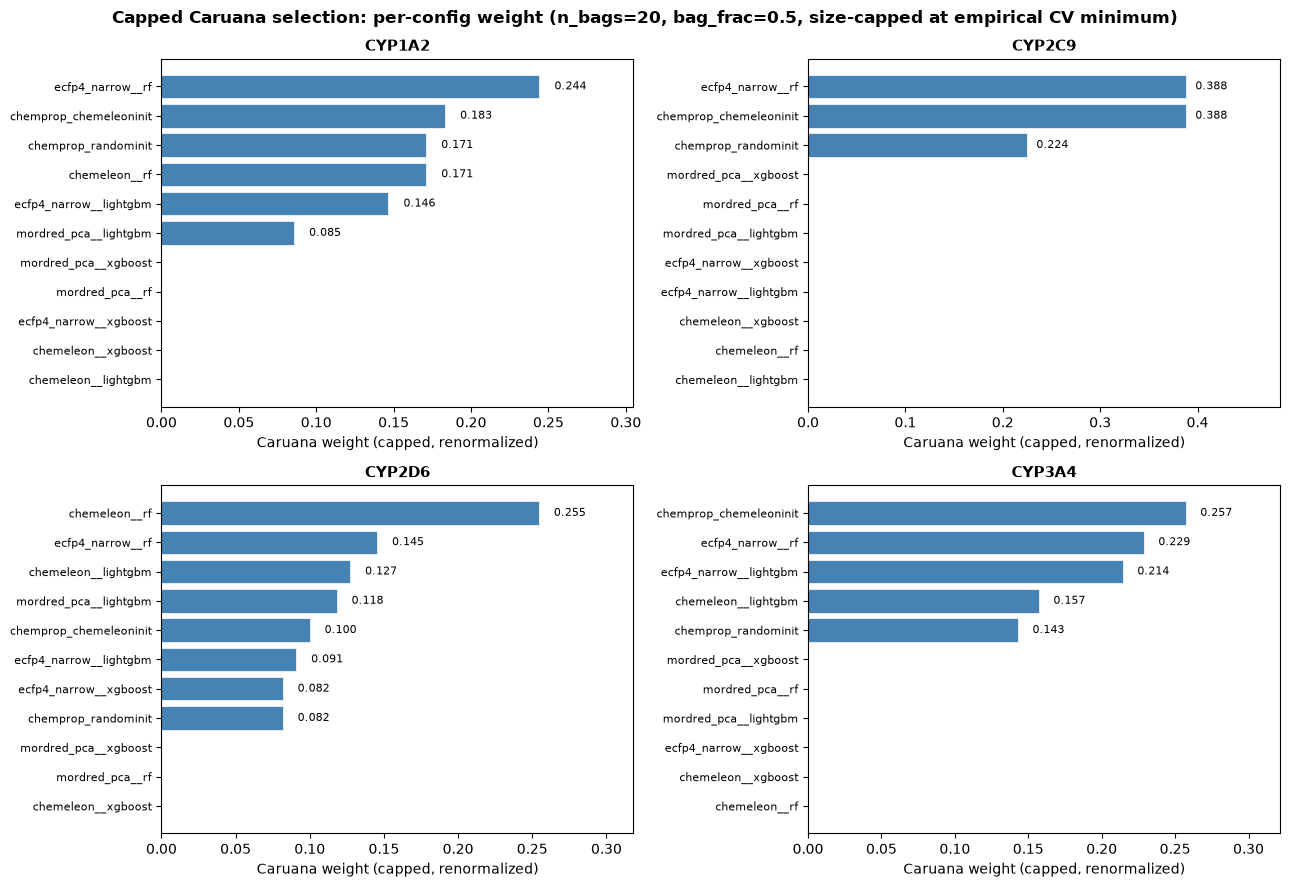

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/figures/weights_by_isoform.png (OVERWRITES the uncapped version)


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, isoform in zip(axes.flat, ISOFORMS):
    w = pd.Series(results[isoform]["weights"]).sort_values(ascending=True)
    colors = ["steelblue" if v > 0 else "lightgray" for v in w.to_numpy()]
    ax.barh(w.index, w.to_numpy(), color=colors, edgecolor="white", linewidth=0.5)
    for i, v in enumerate(w.to_numpy()):
        if v > 0:
            ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, max(w.max() * 1.25, 0.1))
    ax.set_title(isoform, fontsize=11, fontweight="bold")
    ax.set_xlabel("Caruana weight (capped, renormalized)")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(f"Capped Caruana selection: per-config weight (n_bags={N_BAGS}, bag_frac={BAG_FRAC}, size-capped at empirical CV minimum)", fontsize=12, fontweight="bold")
plt.tight_layout()
path = FIG_OUT / "weights_by_isoform.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path} (OVERWRITES the uncapped version)")


**What this shows:** the capped, renormalized weights -- fewer non-zero bars
than the original uncapped version (compare against `weights_uncapped.csv`),
each isoform's ensemble now stopping at its own empirical CV-minimizing
size.

## Required plot 2 of 3 -- before/after 25-fold ST-RAE: 08's ensemble vs. capped Caruana vs. single-best-of-11

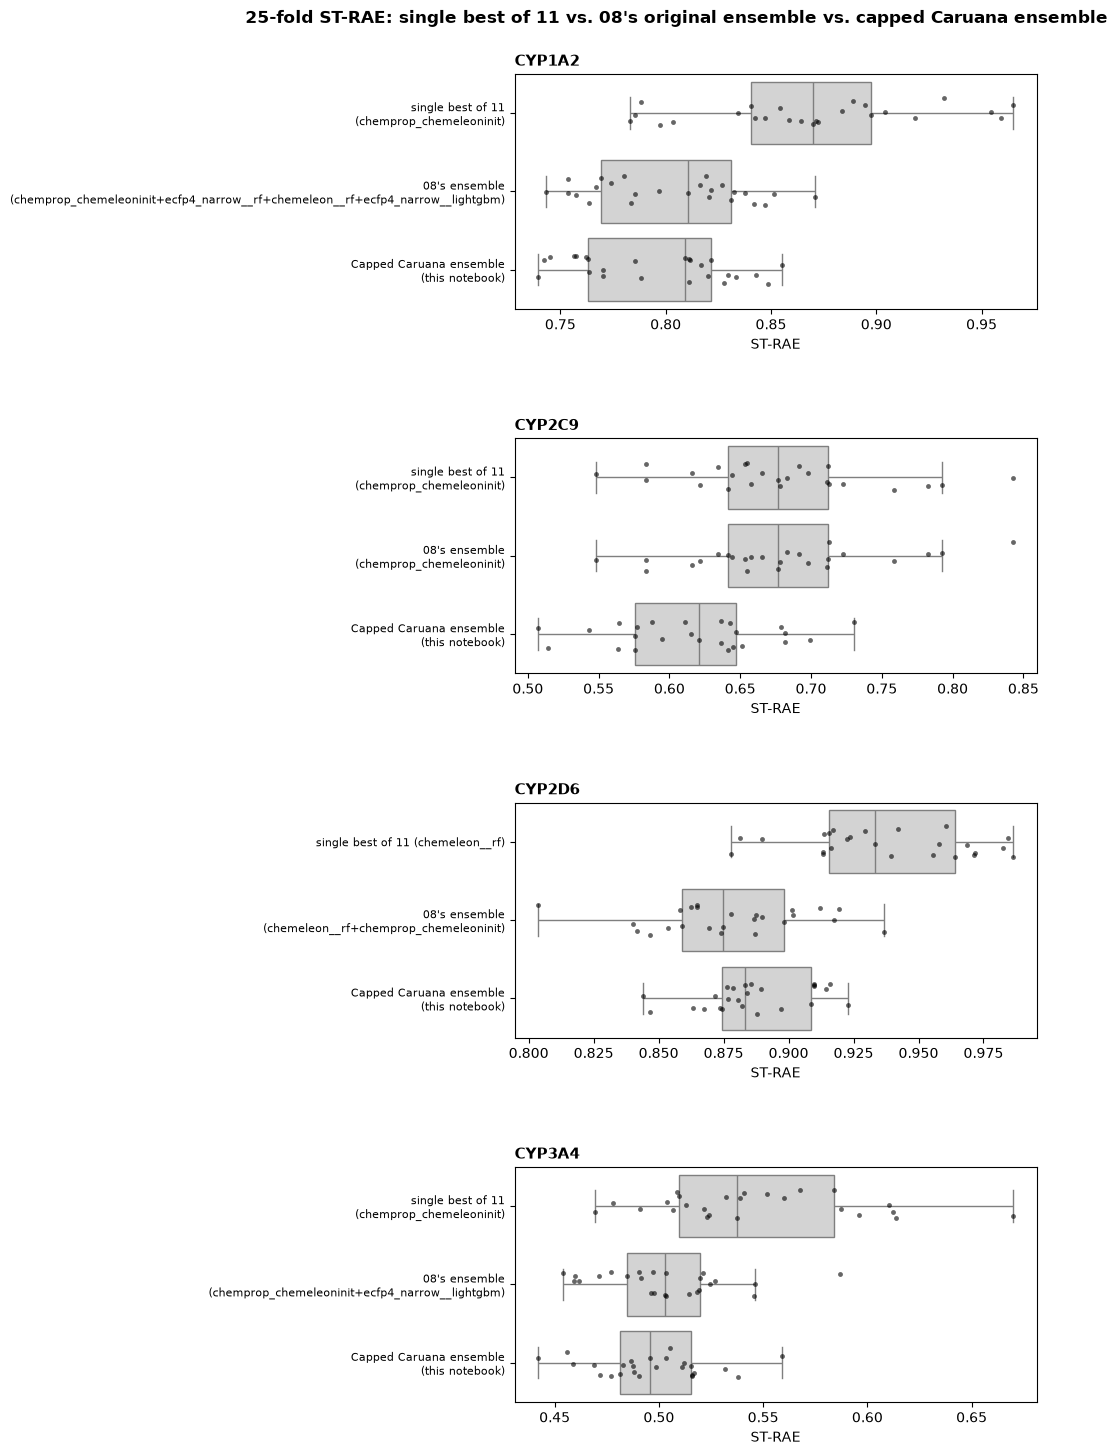

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/11b_caruana_selection/figures/before_after_all_isoforms.png (OVERWRITES the uncapped version)


In [17]:
import textwrap

def wrap_label(text: str, width: int = 34) -> str:
    return "\n".join(textwrap.wrap(text, width=width, break_long_words=False))

fig, axes = plt.subplots(4, 1, figsize=(9, 16))
for ax, isoform in zip(axes, ISOFORMS):
    r = results[isoform]
    dist_df = pd.concat([
        pd.DataFrame({"ST-RAE": r["single_best_fold_scores"]["ST-RAE"].to_numpy(), "source": wrap_label(f"single best of 11 ({r['single_best_tag']})")}),
        pd.DataFrame({"ST-RAE": r["combo08_fold_scores"]["ST-RAE"].to_numpy(), "source": wrap_label(f"08's ensemble ({r['combo08_label']})")}),
        pd.DataFrame({"ST-RAE": r["caruana_fold_scores"]["ST-RAE"].to_numpy(), "source": "Capped Caruana ensemble\n(this notebook)"}),
    ], ignore_index=True)
    order = dist_df["source"].unique().tolist()
    sns.boxplot(data=dist_df, x="ST-RAE", y="source", order=order, ax=ax, color="lightgray", fliersize=0, linewidth=1)
    sns.stripplot(data=dist_df, x="ST-RAE", y="source", order=order, ax=ax, color="black", size=3.5, alpha=0.6, jitter=0.2)
    ax.set_title(isoform, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("25-fold ST-RAE: single best of 11 vs. 08's original ensemble vs. capped Caruana ensemble", fontsize=12, fontweight="bold")
fig.subplots_adjust(left=0.32, hspace=0.55, top=0.94)
path = FIG_OUT / "before_after_all_isoforms.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path} (OVERWRITES the uncapped version)")


**What this shows:** the fold-level spread behind each isoform's capped-ensemble
summary numbers -- whether the capped Caruana distribution is visibly shifted
from the other two is what the paired tests below actually test rather than
eyeballing.

## Explicit per-isoform verdicts (capped ensemble)

Stated plainly, not rounded up: a non-significant or negative delta is
reported as "no different" or "worse," not glossed over.

In [18]:
from IPython.display import Markdown, display

verdict_lines = []
for isoform in ISOFORMS:
    r = results[isoform]
    vs08, vsb = r["vs_08"], r["vs_single_best"]

    if vs08["significant"] and vs08["delta_mean"] < 0:
        verdict_08 = f"**beats 08's original ensemble** ({vs08['before_mean']:.4f} to {vs08['after_mean']:.4f}, {vs08['test']} p={vs08['p_value']:.3g})"
    elif vs08["significant"] and vs08["delta_mean"] > 0:
        verdict_08 = f"is **significantly WORSE** than 08's original ensemble ({vs08['before_mean']:.4f} to {vs08['after_mean']:.4f}, {vs08['test']} p={vs08['p_value']:.3g})"
    else:
        verdict_08 = f"is **no different** from 08's original ensemble ({vs08['before_mean']:.4f} vs {vs08['after_mean']:.4f}, {vs08['test']} p={vs08['p_value']:.3g}, not significant)"

    if vsb["significant"] and vsb["delta_mean"] < 0:
        verdict_best = f"**beats the single best of the 11-config pool** ({vsb['before_mean']:.4f} to {vsb['after_mean']:.4f}, {vsb['test']} p={vsb['p_value']:.3g})"
    elif vsb["significant"] and vsb["delta_mean"] > 0:
        verdict_best = f"is **significantly WORSE** than the single best of the 11-config pool ({vsb['before_mean']:.4f} to {vsb['after_mean']:.4f}, {vsb['test']} p={vsb['p_value']:.3g})"
    else:
        verdict_best = f"is **no different** from the single best of the 11-config pool ({vsb['before_mean']:.4f} vs {vsb['after_mean']:.4f}, {vsb['test']} p={vsb['p_value']:.3g}, not significant)"

    verdict_lines.append(f"- **{isoform}**: the capped Caruana ensemble {verdict_08}, and {verdict_best}.")

display(Markdown("\n".join(verdict_lines)))


- **CYP1A2**: the capped Caruana ensemble **beats 08's original ensemble** (0.8022 to 0.7952, paired t-test p=0.000152), and **beats the single best of the 11-config pool** (0.8685 to 0.7952, paired t-test p=1.24e-09).
- **CYP2C9**: the capped Caruana ensemble **beats 08's original ensemble** (0.6787 to 0.6169, paired t-test p=5.23e-10), and **beats the single best of the 11-config pool** (0.6787 to 0.6169, paired t-test p=5.23e-10).
- **CYP2D6**: the capped Caruana ensemble is **significantly WORSE** than 08's original ensemble (0.8772 to 0.8862, paired t-test p=0.0463), and **beats the single best of the 11-config pool** (0.9372 to 0.8862, paired t-test p=3.55e-13).
- **CYP3A4**: the capped Caruana ensemble is **no different** from 08's original ensemble (0.5029 vs 0.4964, paired t-test p=0.0835, not significant), and **beats the single best of the 11-config pool** (0.5461 to 0.4964, paired t-test p=7.21e-06).